## Reproducing results from the O'Shea et al paper

## Setup

In [1]:
import h5py
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
from torch.utils.data import TensorDataset, DataLoader, random_split

print('PyTorch version:', torch.__version__)
Path('figures').mkdir(exist_ok=True)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5070 Laptop GPU


## Load Dataset
 The dataset is sorted by class. If you just load the first 500k examples you only get the first 5 classes. You have to sample evenly from each class block.

In [2]:
f = h5py.File('data/GOLD_XYZ_OSC.0001_1024.hdf5', 'r')

total = f['X'].shape[0]
per_class = total // 24
samples_per_class = 4000

classes = ['OOK','4ASK','8ASK','BPSK','QPSK','8PSK',
           '16PSK','32PSK','16APSK','32APSK','64APSK',
           '128APSK','16QAM','32QAM','64QAM','128QAM',
           '256QAM','AM-SSB-WC','AM-SSB-SC','AM-DSB-WC',
           'AM-DSB-SC','FM','GMSK','OQPSK']

X_bal, y_bal, snr_bal = [], [], []

for i in range(24):
    start = i * per_class
    idx = np.linspace(start, start + per_class - 1, samples_per_class, dtype=int)
    X_bal.append(f['X'][idx])
    y_bal.append(np.full(samples_per_class, i))
    snr_bal.append(f['Z'][idx].squeeze())

X_bal   = np.concatenate(X_bal)
y_bal   = np.concatenate(y_bal)
snr_bal = np.concatenate(snr_bal)

X_tensor = torch.FloatTensor(X_bal).permute(0, 2, 1)
y_tensor = torch.LongTensor(y_bal)
device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Loaded {len(X_bal):,} examples, {len(classes)} classes')
print(f'X shape: {X_tensor.shape}')
print(f'SNR range: {snr_bal.min():.0f} to {snr_bal.max():.0f} dB')

Loaded 96,000 examples, 24 classes
X shape: torch.Size([96000, 2, 1024])
SNR range: -20 to 30 dB


## Constellation Diagrams

Reproduces Figure 23. Each modulation has a different I/Q shape 

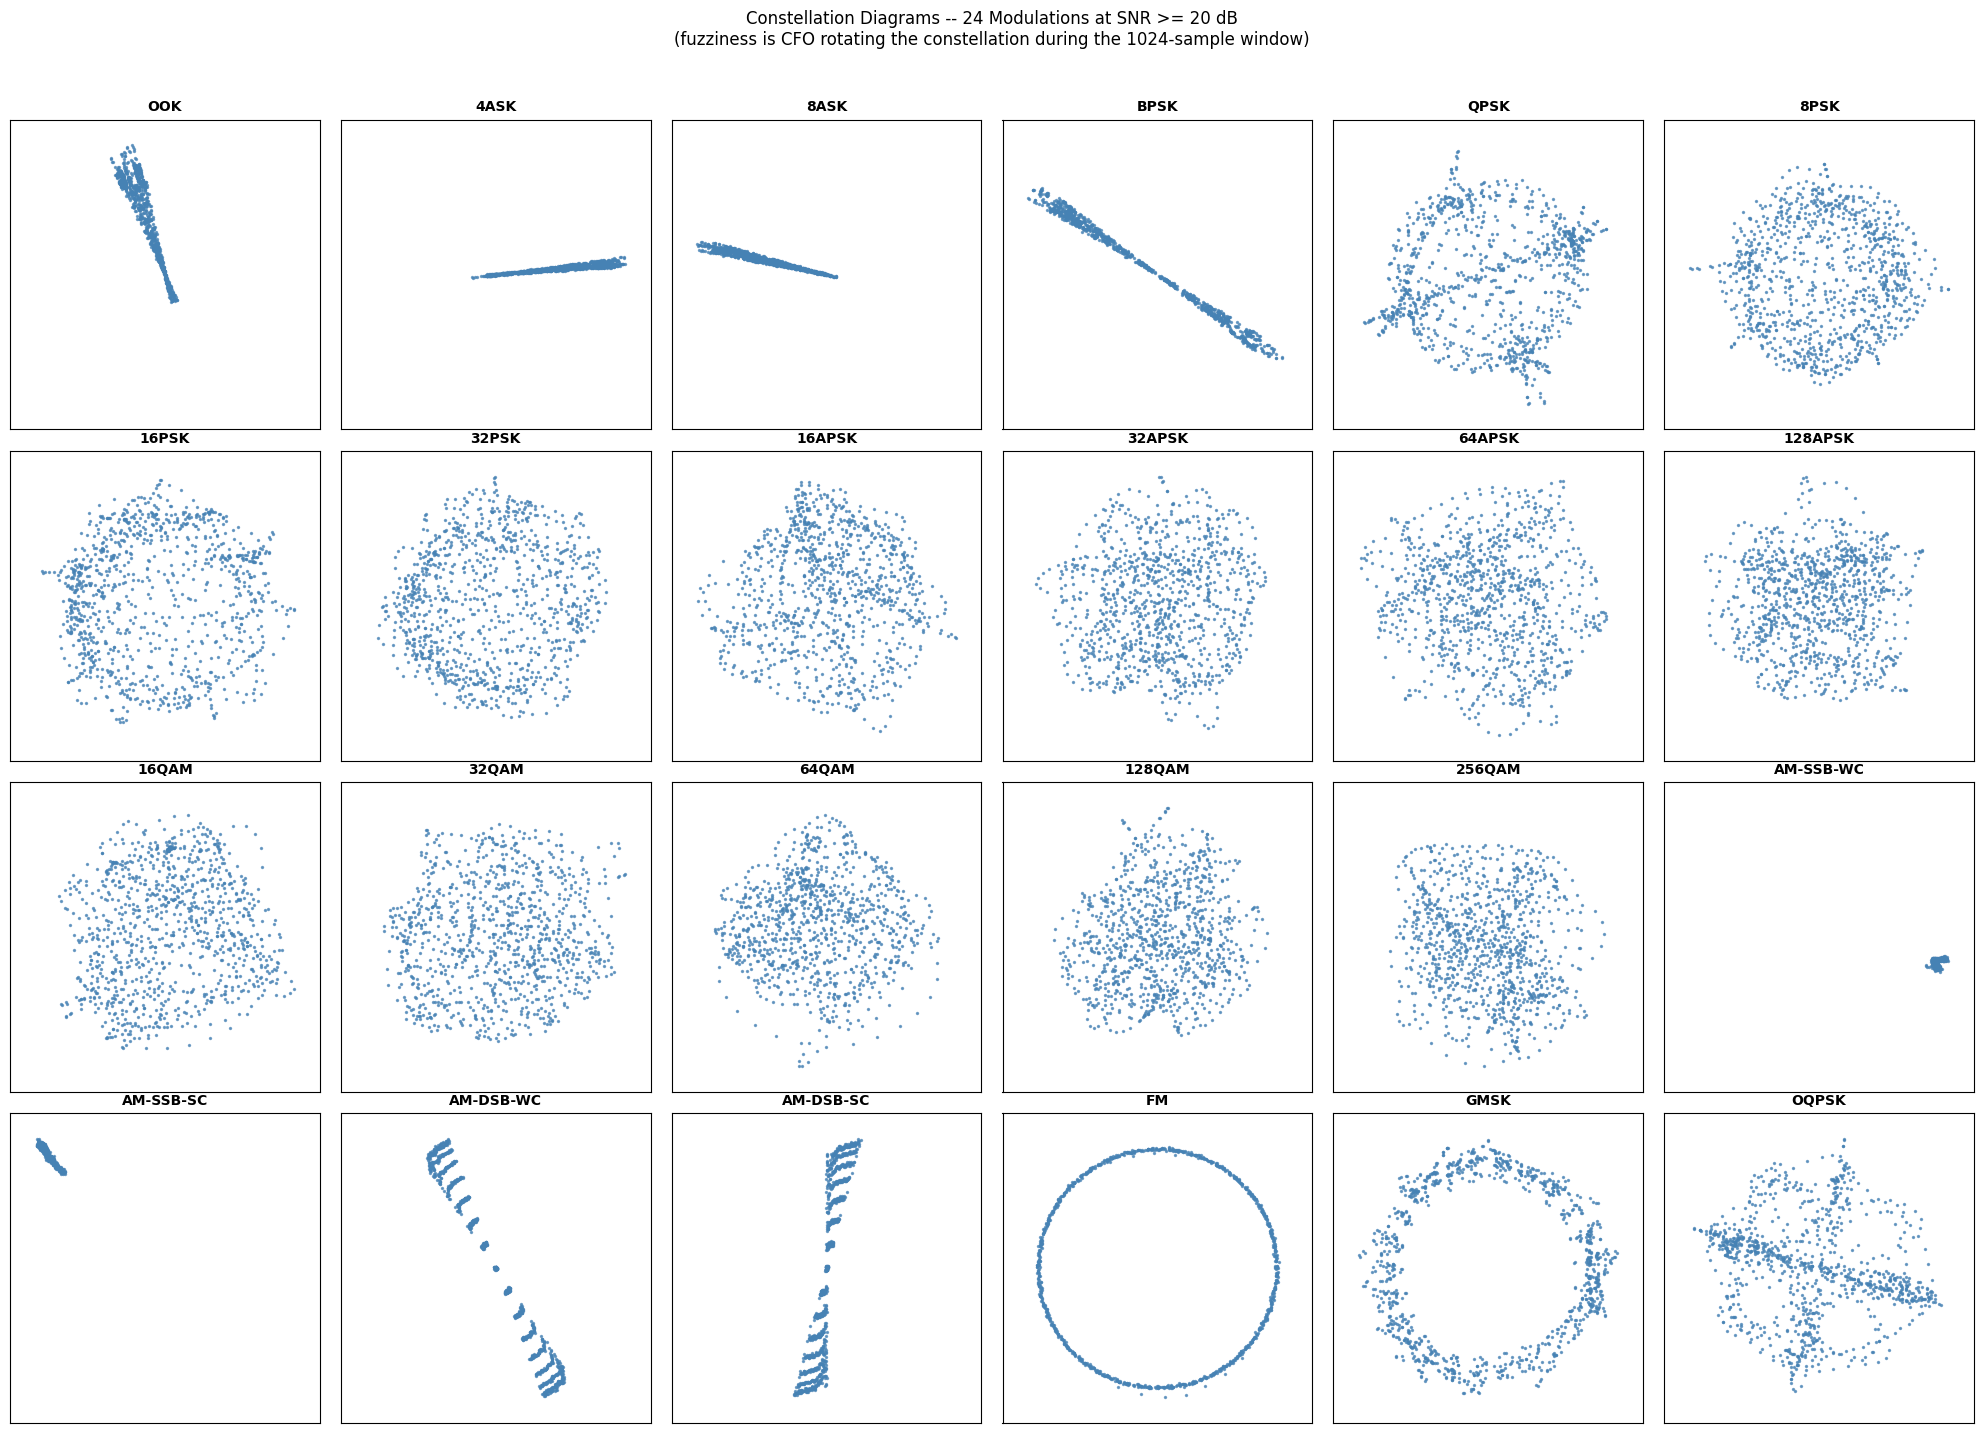

In [3]:
fig, axes = plt.subplots(4, 6, figsize=(20, 14))
axes = axes.flatten()

for idx, name in enumerate(classes):
    start   = idx * per_class
    X_class = f['X'][start:start + per_class]
    Z_class = f['Z'][start:start + per_class].squeeze()
    mask    = Z_class >= 20
    if mask.sum() == 0:
        mask = Z_class >= 0
    ex  = X_class[np.where(mask)[0][0]]
    I, Q = ex[:, 0], ex[:, 1]
    lim = max(np.abs(I).max(), np.abs(Q).max()) * 1.2 or 1.0
    axes[idx].scatter(I, Q, s=2, alpha=0.7, c='steelblue')
    axes[idx].set_title(name, fontsize=10, fontweight='bold')
    axes[idx].set_xlim(-lim, lim)
    axes[idx].set_ylim(-lim, lim)
    axes[idx].set_aspect('equal')
    axes[idx].grid(True, alpha=0.2)
    axes[idx].set_xticks([])
    axes[idx].set_yticks([])

plt.suptitle('Constellation Diagrams -- 24 Modulations at SNR >= 20 dB\n'
             '(fuzziness is CFO rotating the constellation during the 1024-sample window)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('figures/constellation_diagrams.png', dpi=150, bbox_inches='tight')
plt.show()

## ResNet Architecture (Table 4 from paper)

The key thing here is the skip connection. Solves vanishing gradients so you can train very deep networks.

In [4]:
class ResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv1d(channels, channels, 3, padding=1)
        self.bn1   = nn.BatchNorm1d(channels)
        self.conv2 = nn.Conv1d(channels, channels, 3, padding=1)
        self.bn2   = nn.BatchNorm1d(channels)
        self.relu  = nn.ReLU()
        self.pool  = nn.MaxPool1d(2)
        self.skip  = nn.Conv1d(channels, channels, 1)

    def forward(self, x):
        res = self.skip(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.pool(self.relu(out + res))


class RadioResNet(nn.Module):
    def __init__(self, num_classes=24, num_stacks=6):
        super().__init__()
        self.input_conv = nn.Sequential(
            nn.Conv1d(2, 32, 1), nn.BatchNorm1d(32), nn.ReLU()
        )
        self.res_stacks = nn.Sequential(*[ResBlock(32) for _ in range(num_stacks)])
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(128), nn.SELU(), nn.AlphaDropout(0.1),
            nn.Linear(128, 128), nn.SELU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.res_stacks(self.input_conv(x)))


model = RadioResNet().to(device)
with torch.no_grad():
    _ = model(X_tensor[:2].to(device))

print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Parameters: 129,784


## Train with Cartesian I/Q (paper method)

96k examples vs paper's 1M+. Per Figure 16 of the paper this gives ~55-70% at high SNR.

In [5]:
dataset    = TensorDataset(X_tensor, y_tensor)
train_size = int(0.8 * len(dataset))
test_size  = len(dataset) - train_size
train_set, test_set = random_split(dataset, [train_size, test_size],
                                   generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_set, batch_size=512, shuffle=True,  num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=512, shuffle=False, num_workers=0, pin_memory=True)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

print(f'Train: {train_size:,} | Test: {test_size:,}')
print('-' * 50)
for epoch in range(30):
    model.train()
    loss_sum, correct, total = 0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out  = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item()
        correct  += (out.argmax(1) == yb).sum().item()
        total    += len(yb)
    scheduler.step()
    if epoch % 5 == 0 or epoch == 29:
        print(f'Epoch {epoch+1:2d}/30 | Loss: {loss_sum/len(train_loader):.4f} | Acc: {correct/total*100:.1f}%')
print('-' * 50)

Train: 76,800 | Test: 19,200
--------------------------------------------------
Epoch  1/30 | Loss: 2.3146 | Acc: 22.6%
Epoch  6/30 | Loss: 1.6882 | Acc: 40.3%
Epoch 11/30 | Loss: 1.5566 | Acc: 44.9%
Epoch 16/30 | Loss: 1.4781 | Acc: 47.7%
Epoch 21/30 | Loss: 1.4114 | Acc: 50.3%
Epoch 26/30 | Loss: 1.3692 | Acc: 52.0%
Epoch 30/30 | Loss: 1.3575 | Acc: 52.3%
--------------------------------------------------


## Accuracy vs SNR: Figure 6

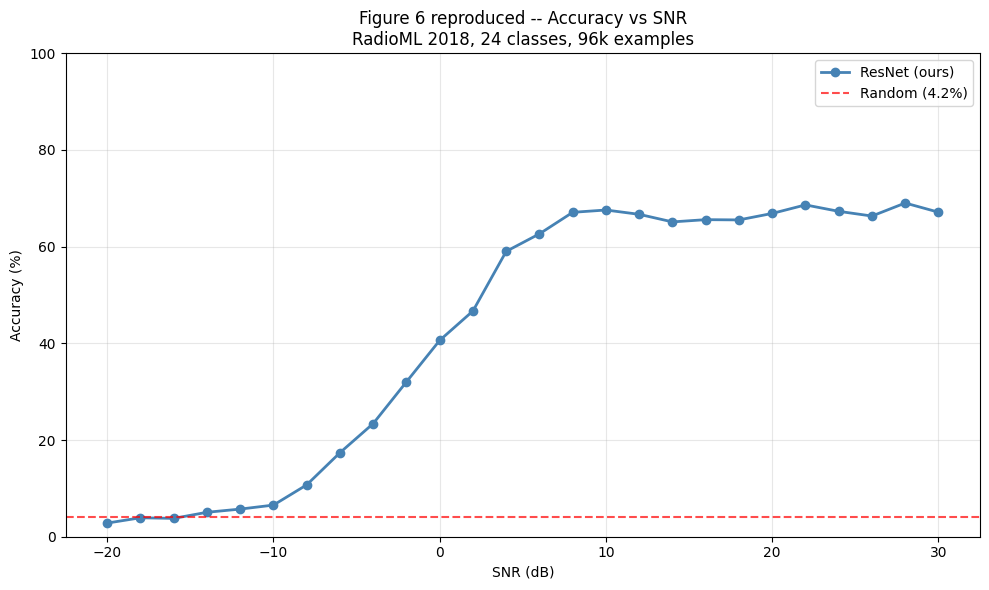

Avg accuracy at SNR >= 10dB: 66.9%


In [6]:
model.eval()
preds_all, labels_all = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        preds_all.extend(model(xb.to(device)).argmax(1).cpu().numpy())
        labels_all.extend(yb.numpy())

preds_all  = np.array(preds_all)
labels_all = np.array(labels_all)
test_snrs  = snr_bal[test_set.indices]
snr_levels = sorted(set(test_snrs.astype(int)))
snr_accs   = {s: (preds_all[test_snrs.astype(int)==s] ==
                  labels_all[test_snrs.astype(int)==s]).mean()
              for s in snr_levels if (test_snrs.astype(int)==s).sum() > 0}

plt.figure(figsize=(10, 6))
plt.plot(list(snr_accs.keys()), [v*100 for v in snr_accs.values()],
         'o-', color='steelblue', linewidth=2, markersize=6, label='ResNet (ours)')
plt.axhline(y=100/24, color='red', linestyle='--', alpha=0.7, label='Random (4.2%)')
plt.xlabel('SNR (dB)')
plt.ylabel('Accuracy (%)')
plt.title('Figure 6 reproduced -- Accuracy vs SNR\nRadioML 2018, 24 classes, 96k examples')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig('figures/accuracy_vs_snr.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Avg accuracy at SNR >= 10dB: {np.mean([v for k,v in snr_accs.items() if k>=10])*100:.1f}%')

## Confusion Matrix: Figure 15

Three confusion groups from the paper all show up:
1. 16PSK/32PSK  both are rings, hard to tell apart
2. High order QAM dense grids look similar when rotated by CFO
3. AM-SSB-WC/SC only difference is whether carrier is present

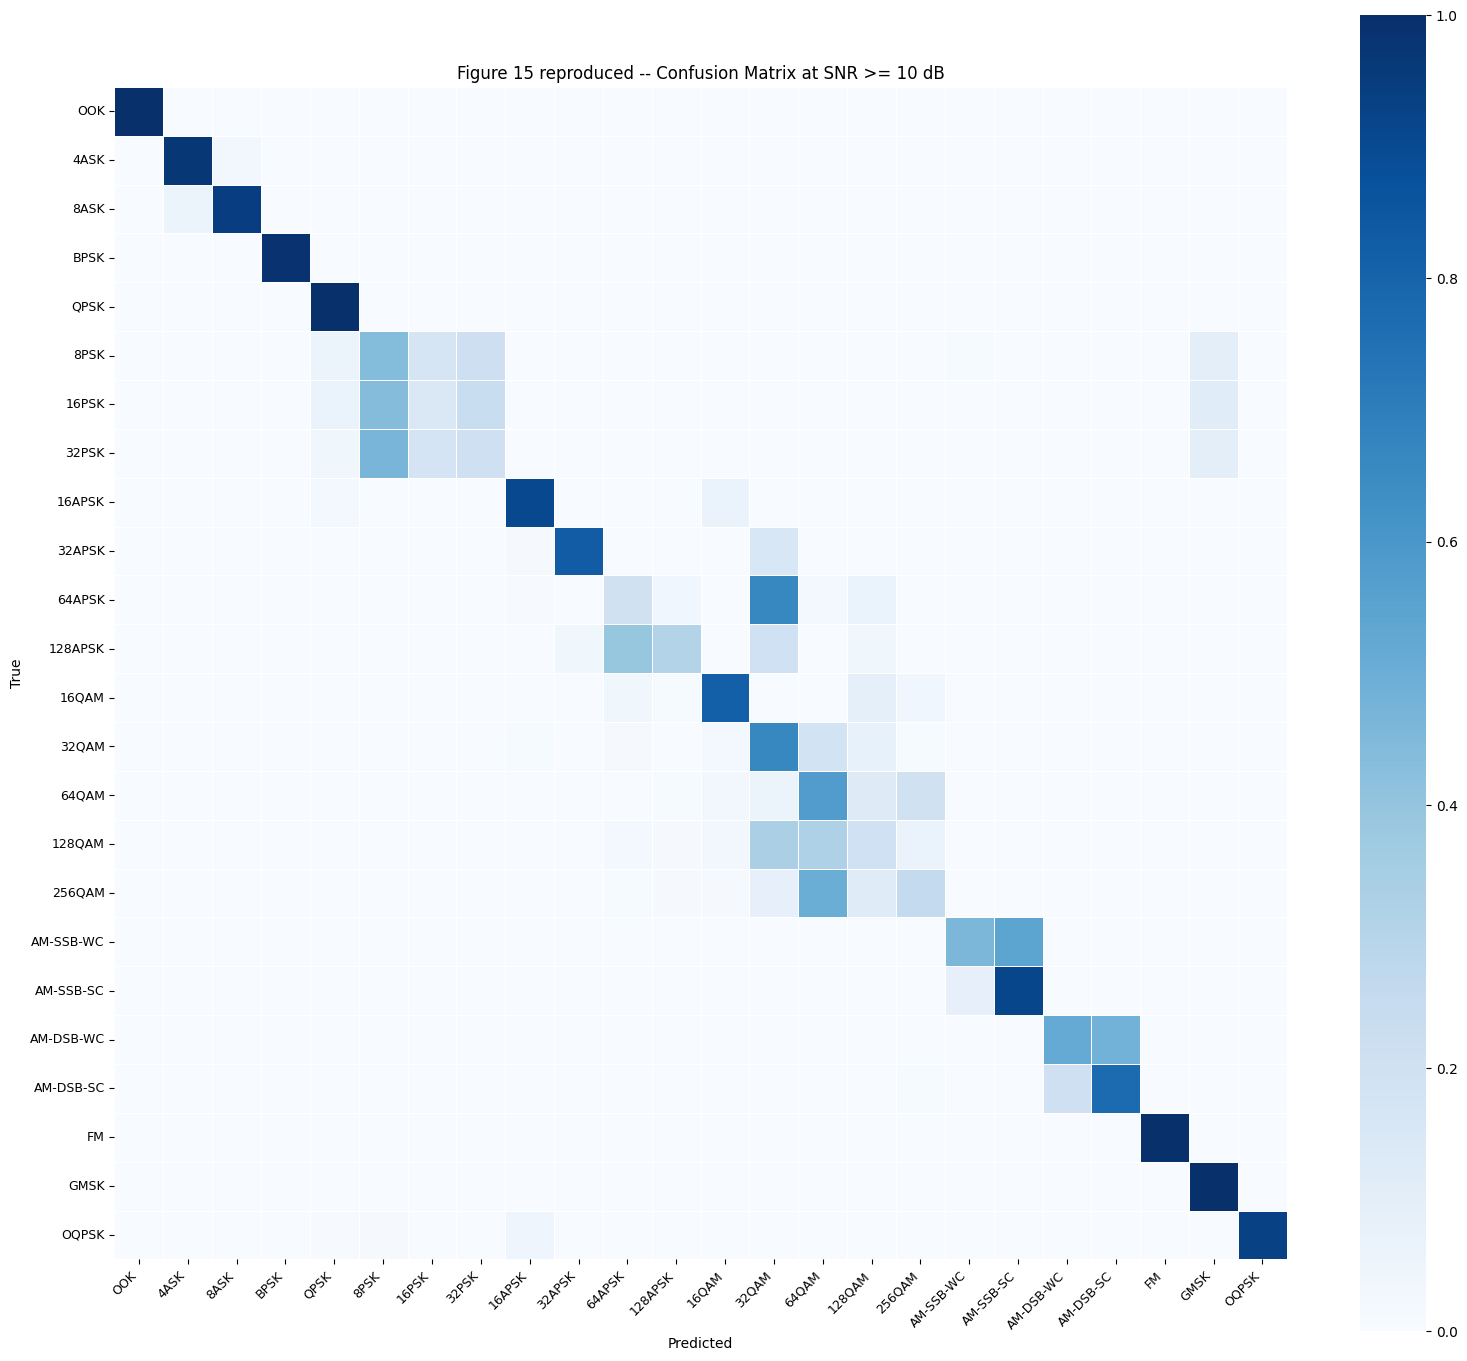

Worst confused pairs:
  8ASK -> 4ASK: 5.8%
  8PSK -> QPSK: 6.1%
  8PSK -> 16PSK: 16.9%
  8PSK -> 32PSK: 21.5%
  8PSK -> GMSK: 10.5%
  16PSK -> QPSK: 6.3%
  16PSK -> 8PSK: 43.7%
  16PSK -> 32PSK: 23.7%
  16PSK -> GMSK: 11.7%
  32PSK -> 8PSK: 46.8%
  32PSK -> 16PSK: 17.6%
  32PSK -> GMSK: 10.3%
  16APSK -> 16QAM: 6.8%
  32APSK -> 32QAM: 16.0%
  64APSK -> 32QAM: 66.6%
  64APSK -> 128QAM: 6.7%
  128APSK -> 64APSK: 39.3%
  128APSK -> 32QAM: 20.5%
  16QAM -> 128QAM: 9.2%
  32QAM -> 64QAM: 18.8%
  32QAM -> 128QAM: 8.0%
  64QAM -> 32QAM: 5.7%
  64QAM -> 128QAM: 12.6%
  64QAM -> 256QAM: 19.8%
  128QAM -> 32QAM: 33.2%
  128QAM -> 64QAM: 32.4%
  128QAM -> 256QAM: 6.5%
  256QAM -> 32QAM: 8.6%
  256QAM -> 64QAM: 50.0%
  256QAM -> 128QAM: 12.0%
  AM-SSB-WC -> AM-SSB-SC: 54.0%
  AM-SSB-SC -> AM-SSB-WC: 8.4%
  AM-DSB-WC -> AM-DSB-SC: 48.4%
  AM-DSB-SC -> AM-DSB-WC: 21.0%


In [7]:
mask_high = test_snrs >= 10
cm = confusion_matrix(labels_all[mask_high], preds_all[mask_high], normalize='true')

plt.figure(figsize=(16, 14))
sns.heatmap(cm, xticklabels=classes, yticklabels=classes,
            cmap='Blues', vmin=0, vmax=1, linewidths=0.5, square=True)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Figure 15 reproduced -- Confusion Matrix at SNR >= 10 dB')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('figures/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('Worst confused pairs:')
cm2 = cm.copy()
np.fill_diagonal(cm2, 0)
for i in range(24):
    for j in range(24):
        if cm2[i][j] > 0.05:
            print(f'  {classes[i]} -> {classes[j]}: {cm2[i][j]*100:.1f}%')

## Use polar

Section 5E of the paper asks: would polar (amplitude + phase) work better than Cartesian I/Q? I tested this with the exact same ResNet, same data, same split.

polar features exist in literature (accumulated polar feature paper reports ~3% improvement). What's different here is a direct controlled comparison using the exact same ResNet as the original paper on the full 24-class dataset.

In [8]:
def to_polar(x):
    I, Q  = x[:, 0, :], x[:, 1, :]
    amp   = torch.sqrt(I**2 + Q**2)
    phase = torch.atan2(Q, I) / np.pi
    return torch.stack([amp, phase], dim=1)

X_polar = to_polar(X_tensor)

model_p = RadioResNet().to(device)
with torch.no_grad():
    _ = model_p(X_polar[:2].to(device))

ds_p = TensorDataset(X_polar, y_tensor)
tr_p, te_p = random_split(ds_p, [train_size, test_size],
                          generator=torch.Generator().manual_seed(42))
trl_p = DataLoader(tr_p, batch_size=512, shuffle=True,  num_workers=0, pin_memory=True)
tel_p = DataLoader(te_p, batch_size=512, shuffle=False, num_workers=0, pin_memory=True)

opt_p = torch.optim.Adam(model_p.parameters(), lr=0.001)
sch_p = torch.optim.lr_scheduler.CosineAnnealingLR(opt_p, T_max=30)

print('Training polar model...')
print('-' * 50)
for epoch in range(30):
    model_p.train()
    loss_sum, correct, total = 0, 0, 0
    for xb, yb in trl_p:
        xb, yb = xb.to(device), yb.to(device)
        opt_p.zero_grad()
        out  = model_p(xb)
        loss = criterion(out, yb)
        loss.backward()
        opt_p.step()
        loss_sum += loss.item()
        correct  += (out.argmax(1) == yb).sum().item()
        total    += len(yb)
    sch_p.step()
    if epoch % 5 == 0 or epoch == 29:
        print(f'Epoch {epoch+1:2d}/30 | Loss: {loss_sum/len(trl_p):.4f} | Acc: {correct/total*100:.1f}%')
print('-' * 50)

Training polar model...
--------------------------------------------------
Epoch  1/30 | Loss: 2.2389 | Acc: 25.8%
Epoch  6/30 | Loss: 1.6117 | Acc: 43.7%
Epoch 11/30 | Loss: 1.4873 | Acc: 47.7%
Epoch 16/30 | Loss: 1.4028 | Acc: 50.7%
Epoch 21/30 | Loss: 1.3421 | Acc: 52.9%
Epoch 26/30 | Loss: 1.2956 | Acc: 54.7%
Epoch 30/30 | Loss: 1.2820 | Acc: 55.2%
--------------------------------------------------


## Final Comparison Plot

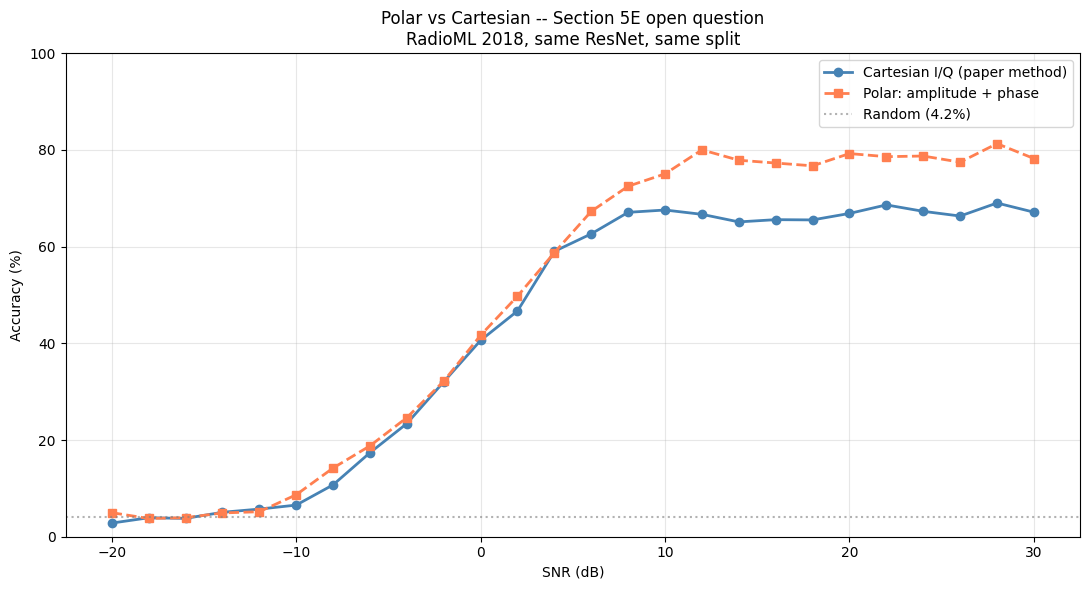

Cartesian: 66.9%
Polar:     78.2%
Polar system is better than cartesian by +11.3%

Ran twice before also: +6.4% and +7.1%
Needs more runs and more data to be a strong claim.


In [11]:
model_p.eval()
pp, lp = [], []
with torch.no_grad():
    for xb, yb in tel_p:
        pp.extend(model_p(xb.to(device)).argmax(1).cpu().numpy())
        lp.extend(yb.numpy())

pp     = np.array(pp)
lp     = np.array(lp)
snrs_p = snr_bal[te_p.indices]
snr_accs_p = {s: (pp[snrs_p.astype(int)==s] == lp[snrs_p.astype(int)==s]).mean()
              for s in snr_levels if (snrs_p.astype(int)==s).sum() > 0}

plt.figure(figsize=(11, 6))
plt.plot(list(snr_accs.keys()),   [v*100 for v in snr_accs.values()],
         'o-',  color='steelblue', linewidth=2, markersize=6, label='Cartesian I/Q (paper method)')
plt.plot(list(snr_accs_p.keys()), [v*100 for v in snr_accs_p.values()],
         's--', color='coral',     linewidth=2, markersize=6, label='Polar: amplitude + phase')
plt.axhline(y=100/24, color='gray', linestyle=':', alpha=0.6, label='Random (4.2%)')
plt.xlabel('SNR (dB)')
plt.ylabel('Accuracy (%)')
plt.title('Polar vs Cartesian -- Section 5E open question\nRadioML 2018, same ResNet, same split')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig('figures/polar_vs_cartesian.png', dpi=150, bbox_inches='tight')
plt.show()

cart  = np.mean([v for k,v in snr_accs.items()   if k >= 10])
polar = np.mean([v for k,v in snr_accs_p.items() if k >= 10])
print(f'Cartesian: {cart*100:.1f}%')
print(f'Polar:     {polar*100:.1f}%')
print(f'Polar system is better than cartesian by {(polar-cart)*100:+.1f}%')
print()
print('Ran twice before also: +6.4% and +7.1%')
print('Needs more runs and more data to be a strong claim.')

In [ ]:
# ============================================================
# PAPER 2: Shankar et al. 2024 -- LResNet
# Reproducing: LResNet architecture + FGSM adversarial attack
# Dataset: same RadioML 2018.01A already loaded above
# ============================================================

import torch.nn.functional as F

class RBlockA(nn.Module):
    """No spatial reduction -- same channels in and out."""
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1)
        self.bn1   = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1)
        self.bn2   = nn.BatchNorm2d(channels)

    def forward(self, x):
        out = F.hardtanh(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return F.hardtanh(out + x)


class RBlockB(nn.Module):
    """Spatial reduction by 2 + channel expansion."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1   = nn.Conv2d(in_ch, out_ch, 3, stride=2, padding=1)
        self.bn1     = nn.BatchNorm2d(out_ch)
        self.conv2   = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bn2     = nn.BatchNorm2d(out_ch)
        self.skip    = nn.Conv2d(in_ch, out_ch, 1, stride=2)
        self.bn_skip = nn.BatchNorm2d(out_ch)

    def forward(self, x):
        res = self.bn_skip(self.skip(x))
        out = F.hardtanh(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return F.hardtanh(out + res)


class LResNet(nn.Module):
    """
    LResNet from Table I of Shankar et al. 2024.
    Key difference from O'Shea ResNet:
    - Uses 2D convolutions (treats signal as 2 x 1024 image)
    - 3x3 first layer captures cross I/Q channel patterns
    - Filters grow 32->64->128 with depth
    - Designed for binarization (we use full precision here)
    """
    def __init__(self, num_classes=24):
        super().__init__()
        self.init_conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.Hardtanh()
        )
        self.blocks = nn.Sequential(
            RBlockA(32),
            RBlockB(32, 32),
            RBlockA(32),
            RBlockB(32, 64),
            RBlockA(64),
            RBlockB(64, 64),
            RBlockA(64),
            RBlockB(64, 128),
        )
        self.pool       = nn.AdaptiveAvgPool2d((1, 1))
        self.bn_final   = nn.BatchNorm2d(128)
        self.dropout    = nn.Dropout(0.5)
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        # x: (N, 2, 1024) -> (N, 1, 2, 1024) for 2D conv
        x = x.unsqueeze(1)
        x = self.init_conv(x)
        x = self.blocks(x)
        x = self.pool(x)
        x = self.bn_final(x)
        x = x.flatten(1)
        x = self.dropout(x)
        return self.classifier(x)


lresnet = LResNet(num_classes=24).to(device)
with torch.no_grad():
    _ = lresnet(X_tensor[:2].to(device))

params = sum(p.numel() for p in lresnet.parameters())
print(f'LResNet parameters: {params:,}')
print('Architecture: 2D conv, filters 32->64->128, hardtanh activation')
print('Input reshape: (N, 2, 1024) -> (N, 1, 2, 1024)')